# Loading in the data

In [1]:
from tara_preprocessing import full_preprocessing,make_rbf_correlation_matrix,get_just_ecog_data,get_electrode_normalized_loc,make_patient_correlation_matrix
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import torch
import torch.nn.utils.parametrize as parametrize
import geoopt

In [2]:
data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
print('Downloaded data')
xyz_clean, mapping_clean, kept_global_indices, cleaned = full_preprocessing(ecogs,xyz)
print('Data cleaned')
patient_corr_mat = make_patient_correlation_matrix(xyz_clean,cleaned,mapping_clean)
print('Got Correlation Matrices, done!')

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

In [3]:
from production_make_u import create_u
U_det,loss = create_u(k=10,r=100,lamb=1,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_clean)

Optimizing U


100%|██████████| 1000/1000 [00:03<00:00, 318.03it/s]


In [ ]:
def object_func(C,U,L,lamb,patient_node_num):
    sum = torch.zeros(1,requires_grad=True) #,dtype=torch.float32,
    #sum = torch.tensor(0,requires_grad=True) #,dtype=torch.float32
    iter = 0
    for i in range(14):
        c = C[i] #each patient correlation matrix
        num_nodes = patient_node_num[i]
        u = U[iter:iter+num_nodes,:] #all columns of rows iter+num of nodes + 1 
        sum = sum + (torch.linalg.norm((u@u.T - c),ord='fro'))**2 #+lamb*torch.trace(U.T@L@U)
        iter = iter + num_nodes
    sum = sum + lamb*torch.trace(U.T@L@U)
    return sum


def create_u(k,r,lamb,patient_corr_mat,xyz_clean,object_func):
    ############## Make Graph ##############
    num_nodes = xyz_clean.shape[0] #649
    neigh = NearestNeighbors(n_neighbors=k).fit(xyz_clean)
    indicesofneigh = neigh.kneighbors()[1] #gets the indices of the 10 (or k) neighbors of each node
    # turn indices lists into pairwiase combos
    all_edges = []
    iter = 0
    for indexs in indicesofneigh:
        for num in indexs:
            all_edges.append((iter,num))
        iter += 1
    G = nx.Graph()
    nodes = np.arange(num_nodes)
    G.add_nodes_from(nodes)
    G.add_edges_from(all_edges)
    ############## Preparing function inputs ##############
    Glaplacian = nx.linalg.laplacian_matrix(G).toarray()
    L = torch.tensor(Glaplacian,dtype=torch.float32,requires_grad=False)
    #r = 200
    #lamb = 1
    patient_node_num = []
    C = []
    for corr in patient_corr_mat:
        C.append(torch.tensor(np.array(corr),requires_grad=True))
        patient_node_num.append(corr.shape[0])
    ############## Preparing U and its manifold ##############
    rng = np.random.default_rng()
    U_intial = rng.uniform(1,2,(649,r)) #random values to start with
    U_intial = U_intial/np.linalg.norm(U_intial,axis=1,keepdims=True) #ensuring intial U is normalized
    U_tensor = torch.tensor(U_intial,dtype=torch.float32) 
    sphere = geoopt.manifolds.Sphere()
    #https://geoopt.readthedocs.io/en/latest/manifolds.html?highlight=sphere#geoopt.manifolds.Sphere
    # ^ see the above site for more on the manifolds^
    U = geoopt.ManifoldParameter(U_tensor,manifold=sphere) # geoopt.Sphere()
    ############## Training U ##############
    optimizer = geoopt.optim.RiemannianAdam([U], lr=0.01)
    loss_list = []
    grads = []
    print("Optimizing U")
    for step in tqdm(range(1000)):
        optimizer.zero_grad()
        z = object_func(C,U,L,lamb,patient_node_num) #this is our loss function
        loss_list.append(z.detach())
        z.backward()
        optimizer.step()
    return U.detach()

In [81]:
U_det = create_u(k=10,r=100,lamb=1,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_clean,object_func=object_func)

Optimizing U


100%|██████████| 1000/1000 [00:02<00:00, 367.08it/s]


In [85]:
print("Norm of a Column:")
print(torch.linalg.norm(U_det[1,:]))
print("Norm of a Row:")
print(torch.linalg.norm(U_det[1]))

Norm of a Column:
tensor(1.)
Norm of a Row:
tensor(1.)


In [ ]:
r=100
rng = np.random.default_rng()
U_intial = rng.uniform(1,2,(2,r)) #random values to start with
U_intial = U_intial/np.linalg.norm(U_intial,axis=1,keepdims=True) #ensuring intial U is normalized
U_tensor = torch.tensor(U_intial,dtype=torch.float32) 
#print(U_tensor)
U = torch.empty((2,r))    
with torch.no_grad():
    U[0] = geoopt.ManifoldParameter(U_tensor[0],manifold=geoopt.Sphere())
    U[1] = geoopt.ManifoldParameter(U_tensor[1],manifold=geoopt.Sphere())
U.requires_grad = True
U = U + torch.ones((2,r))    
#print(U.grad_fn)


In [60]:
U_det[0]

tensor([ 0.1213,  0.1119, -0.0028,  0.0695,  0.1012,  0.1686,  0.0465, -0.0016,
         0.0128,  0.0300,  0.0724,  0.0575,  0.0564,  0.1692,  0.0823,  0.1229,
        -0.0162,  0.1229,  0.0379,  0.0824,  0.0456,  0.0854,  0.0735,  0.0357,
        -0.0407,  0.1074, -0.0723, -0.0187,  0.0621,  0.0420,  0.1164,  0.1000,
         0.1089,  0.0436,  0.1338,  0.0801,  0.0567,  0.1056,  0.1074,  0.1250,
         0.0710,  0.0112, -0.0119,  0.0785,  0.0720, -0.0138, -0.0431,  0.0476,
         0.1452,  0.0616,  0.1064,  0.0383,  0.1957,  0.0193,  0.0101,  0.0058,
        -0.0482,  0.0478,  0.1720,  0.0884,  0.0003,  0.0463,  0.0223, -0.0232,
         0.0396,  0.0736,  0.0260,  0.0839,  0.0202,  0.0152,  0.0911,  0.0848,
         0.0238,  0.0358,  0.1493,  0.1469,  0.0937,  0.1055,  0.0751,  0.0266,
         0.1167,  0.0847,  0.0597,  0.0272,  0.0850,  0.1068,  0.0651, -0.0126,
        -0.0316,  0.1118, -0.0031,  0.0257,  0.0580,  0.0360,  0.1317,  0.0730,
         0.1254,  0.0613, -0.0103,  0.10

In [61]:
torch.linalg.norm(U_det[0,:])

tensor(0.8182)

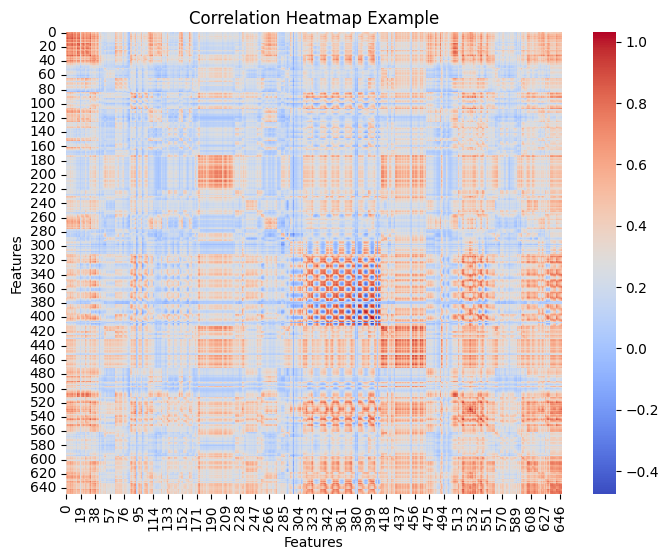

In [65]:
plt.figure(figsize=(8, 6))
sns.heatmap(U_det@U_det.T, cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

# Making the Graph

In [10]:
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
k = 10
num_nodes = 649
neigh = NearestNeighbors(n_neighbors=k).fit(xyz_clean)
indicesofneigh = neigh.kneighbors()[1] #gets the indices of the 10 (or k) neighbors of each node

# turn indices lists into pairwiase combos
all_edges = []
iter = 0
for indexs in indicesofneigh:
    #temp = []
    for num in indexs:
        all_edges.append((iter,num))
    iter += 1
    
G = nx.Graph()
nodes = np.arange(num_nodes)
G.add_nodes_from(nodes)
G.add_edges_from(all_edges)

Glaplacian = nx.linalg.laplacian_matrix(G).toarray() #gets the laplacian of the bain graph for use to use

# Preparing the variables for use in the func

In [ ]:
'''
    U = torch.empty((649,r),requires_grad=True)
    with torch.no_grad():
        for i in range(649):
            U[i] = geoopt.ManifoldParameter(U_tensor[i],manifold=sphere)
    U.requires_grad = True
    '''

# Preparing model parameter U:

In [ ]:
rng = np.random.default_rng()
U = rng.uniform(1,2,(649,r))
U = U/np.linalg.norm(U,axis=1,keepdims=True)
U = torch.tensor(U,dtype=torch.float32)

sphere = geoopt.manifolds.Sphere()
#product_manifold = geoopt.manifolds.ProductManifold([sphere for _ in range(649))
#https://geoopt.readthedocs.io/en/latest/manifolds.html?highlight=sphere#geoopt.manifolds.Sphere
# ^ see the above site for more ^
U = geoopt.ManifoldParameter(
    U,
    manifold=geoopt.Sphere()
)

def object_func(C,U,L,lamb):
    sum = torch.zeros(1,requires_grad=True) #,dtype=torch.float32,
    #sum = torch.tensor(0,requires_grad=True) #,dtype=torch.float32
    iter = 0
    for i in range(14):
        c = C[i] #each patient correlation matrix
        num_nodes = patient_node_num[i]
        u = U[iter:iter+num_nodes,:] #all columns of rows iter+num of nodes + 1 
        sum = sum + (torch.linalg.norm((u@u.T - c),ord='fro'))**2 #+lamb*torch.trace(U.T@L@U)
        iter = iter + num_nodes
    sum = sum + lamb*torch.trace(U.T@L@U)
    return sum


In [49]:
#optimizer = geoopt.optim.RiemannianSGD([params], lr=0.01)
optimizer = geoopt.optim.RiemannianAdam([U], lr=0.01)
loss_list = []
grads = []
for step in tqdm(range(1000)):
    optimizer.zero_grad()
    z = object_func(C,U,L,lamb) #this is our loss function
    loss_list.append(z.detach())
    z.backward()
    optimizer.step()

100%|██████████| 1000/1000 [00:03<00:00, 309.11it/s]


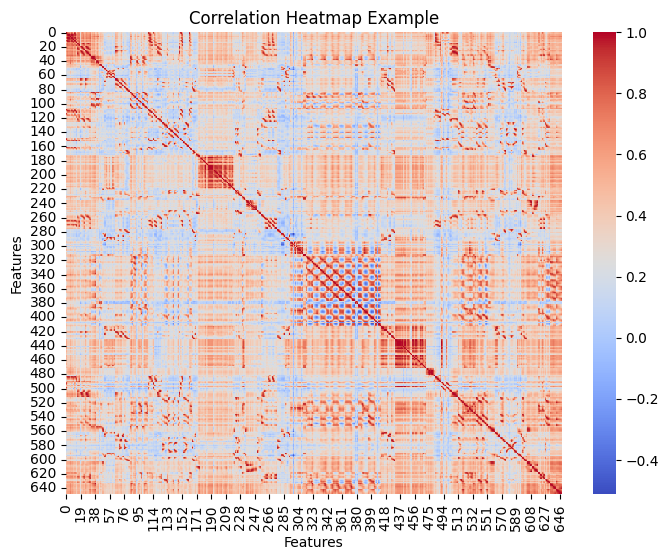

In [50]:
U_detach = U.detach()
plt.figure(figsize=(8, 6))
sns.heatmap(U_detach@U_detach.T, cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

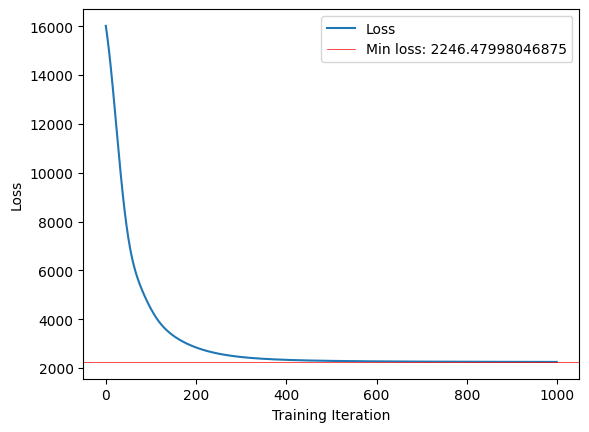

In [51]:
min = np.min(loss_list)
plt.plot(loss_list,label='Loss')
plt.axhline(y=min,c='red',label=f"Min loss: {round(min,2)}",linewidth=.5)
plt.xlabel('Training Iteration')
plt.ylabel('Loss')
plt.legend()

In [36]:
np.diag(U_detach@U_detach.T)

array([0.9999998 , 1.0000004 , 1.0000001 , 0.9999997 , 0.99999976,
       1.        , 1.0000004 , 0.99999994, 1.0000001 , 0.99999976,
       0.99999994, 1.        , 1.0000002 , 1.0000006 , 0.9999999 ,
       0.9999998 , 0.99999976, 0.9999999 , 0.9999999 , 1.0000002 ,
       1.        , 0.99999994, 1.0000001 , 1.0000005 , 1.        ,
       1.0000001 , 1.0000001 , 1.0000001 , 1.0000004 , 1.0000002 ,
       1.        , 1.        , 1.0000001 , 0.99999976, 1.0000005 ,
       0.99999994, 1.        , 1.        , 1.        , 0.9999998 ,
       0.99999994, 1.0000001 , 0.9999999 , 1.0000001 , 0.99999994,
       0.9999999 , 1.0000001 , 0.9999998 , 1.0000004 , 1.        ,
       0.99999976, 0.9999997 , 1.        , 1.0000001 , 1.        ,
       1.0000001 , 1.0000001 , 1.0000004 , 0.9999996 , 0.99999976,
       1.        , 0.99999976, 1.        , 1.0000001 , 1.0000005 ,
       1.0000002 , 1.0000001 , 0.9999996 , 1.0000002 , 1.        ,
       1.        , 0.9999999 , 1.        , 1.0000001 , 1.00000

In [ ]:

patient_node_num = []# this is how many nodes each paitent has
r = 200 #This is the rank of the approximation, or the number of columns of U
L = torch.tensor(Glaplacian,dtype=torch.float32,requires_grad=True)
U = torch.rand((649,r),requires_grad=True)
#U =  torch.nn.Parameter(torch.randn(649, r))
#with torch.no_grad():
    #U = U / torch.linalg.norm(U,axis=1,keepdim=True)
print(U.requires_grad)
C = [] #this is your list of correlation matrixs
lamb = 1
for corr in patient_corr_mat:
    C.append(torch.tensor(np.array(corr),requires_grad=True))
    patient_node_num.append(corr.shape[0])

def object_func(C,U,L,lamb):
    #sum = torch.zeros(1,dtype=torch.float32,requires_grad=True)
    sum = torch.tensor(0,dtype=torch.float32,requires_grad=True)
    iter = 0
    for i in range(14):
        c = C[i] #each patient correlation matrix
        num_nodes = patient_node_num[i]
        u = U[iter:iter+num_nodes,:] #all columns of rows iter+num of nodes + 1 
        sum = sum + (torch.linalg.norm((u@u.T - c),ord='fro'))**2 #+lamb*torch.trace(U.T@L@U)
        iter = iter + num_nodes
    sum = sum +lamb*torch.trace(U.T@L@U)
    return sum

# Training

In [55]:
optimizer = torch.optim.Adam([U], lr=0.001) 
#parametrize.register_parametrization(U, constraint_func)
loss_list = []
grads = []
for step in tqdm(range(1000)):
    optimizer.zero_grad()
    z = object_func(C,U,L,lamb) #this is our loss function
    #z.retain_grad()
    loss_list.append(z.detach())
    z.backward()
    #grads.append(U[0][0].grad)
    optimizer.step()
    #means = torch.linalg.norm(U,axis=1,keepdim=True)
    #print(means.shape)
    #with torch.no_grad():
    #    U = U / torch.linalg.norm(U,axis=1,keepdim=True)
    #print(U.requires_grad)
    

ValueError: can't optimize a non-leaf Tensor

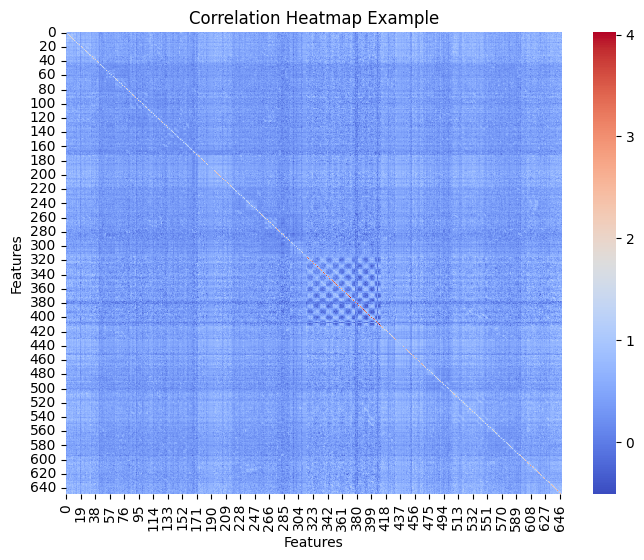

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(U.detach()@U.detach().T, cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

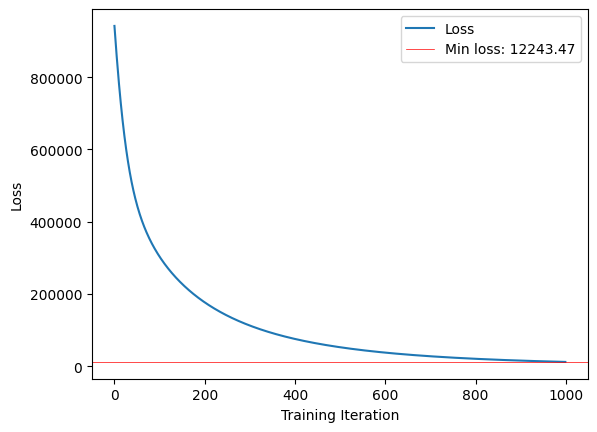

In [33]:
min = np.min(loss_list)
plt.plot(loss_list,label='Loss')
plt.axhline(y=min,c='red',label=f"Min loss: {round(min,2)}",linewidth=.5)
plt.xlabel('Training Iteration')
plt.ylabel('Loss')
plt.legend()

# Backup code

In [ ]:
def object_func(C,U,L,lamb,patient_node_num):
    sum = torch.zeros(1,requires_grad=True) #,dtype=torch.float32,
    #sum = torch.tensor(0,requires_grad=True) #,dtype=torch.float32
    iter = 0
    for i in range(14):
        c = C[i] #each patient correlation matrix
        num_nodes = patient_node_num[i]
        u = U[iter:iter+num_nodes,:] #all columns of rows iter+num of nodes + 1 
        sum = sum + (torch.linalg.norm((u@u.T - c),ord='fro'))**2 #+lamb*torch.trace(U.T@L@U)
        iter = iter + num_nodes
    sum = sum + lamb*torch.trace(U.T@L@U)
    return sum

def create_u(k,r,lamb,patient_corr_mat,xyz_clean,object_func):
    ############## Make Graph ##############
    num_nodes = xyz_clean.shape[0] #649
    neigh = NearestNeighbors(n_neighbors=k).fit(xyz_clean)
    indicesofneigh = neigh.kneighbors()[1] #gets the indices of the 10 (or k) neighbors of each node
    # turn indices lists into pairwiase combos
    all_edges = []
    iter = 0
    for indexs in indicesofneigh:
        for num in indexs:
            all_edges.append((iter,num))
        iter += 1
    G = nx.Graph()
    nodes = np.arange(num_nodes)
    G.add_nodes_from(nodes)
    G.add_edges_from(all_edges)
    ############## Preparing function inputs ##############
    Glaplacian = nx.linalg.laplacian_matrix(G).toarray()
    L = torch.tensor(Glaplacian,dtype=torch.float32,requires_grad=False)
    #r = 200
    #lamb = 1
    patient_node_num = []
    C = []
    for corr in patient_corr_mat:
        C.append(torch.tensor(np.array(corr),requires_grad=True))
        patient_node_num.append(corr.shape[0])
    ############## Preparing U and its manifold ##############
    rng = np.random.default_rng()
    U_intial = rng.uniform(1,2,(649,r)) #random values to start with
    U_intial = U_intial/np.linalg.norm(U_intial,axis=1,keepdims=True) #ensuring intial U is normalized
    U_tensor = torch.tensor(U_intial,dtype=torch.float32) 
    #sphere = geoopt.manifolds.Sphere(dim=-1)
    #https://geoopt.readthedocs.io/en/latest/manifolds.html?highlight=sphere#geoopt.manifolds.Sphere
    # ^ see the above site for more on the manifolds^
    #
    U = geoopt.ManifoldParameter(U_tensor,manifold=geoopt.Sphere()) # geoopt.Sphere()
    ############## Training U ##############
    optimizer = geoopt.optim.RiemannianAdam([U], lr=0.01)
    loss_list = []
    grads = []
    for step in tqdm(range(1000)):
        optimizer.zero_grad()
        z = object_func(C,U,L,lamb,patient_node_num) #this is our loss function
        loss_list.append(z.detach())
        z.backward()
        optimizer.step()
    return U.detach()